<a href="https://colab.research.google.com/github/SharathkumaraKR/Credit-Risk-Model/blob/Feature-Engineering/Credit_Risk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_curve, auc
from sklearn.feature_selection import f_classif
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import chi2_contingency

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "credit_risk_dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "laotse/credit-risk-dataset",
    file_path
)

/tmp/ipykernel_53441/2677142736.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


In [3]:
pd.options.display.max_columns = None

In [4]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
loan_data = df

In [7]:
#get a list of columns that have more than 40% null values
na_values = loan_data.isnull().mean()
na_values[na_values>0.40]

,0


In [8]:
loan_data.dropna(thresh = loan_data.shape[0] * 0.6, axis = 1, inplace = True)

In [9]:
loan_data['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,6453
MEDICAL,6071
VENTURE,5719
PERSONAL,5521
DEBTCONSOLIDATION,5212
HOMEIMPROVEMENT,3605


In [10]:
loan_data['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,16446
MORTGAGE,13444
OWN,2584
OTHER,107


In [11]:
loan_data

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [12]:
X = loan_data.drop('loan_status', axis = 1)
y = loan_data['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

X_train, X_test = X_train.copy(), X_test.copy()

## General Data Cleaning

In [13]:
# first divide training data into categorical and numerical subsets
X_train_cat = X_train.select_dtypes(include = 'object').copy()
X_train_num = X_train.select_dtypes(include = 'number').copy()

In [14]:
X_train_cat

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
15884,MORTGAGE,EDUCATION,A,N
15138,RENT,PERSONAL,B,N
7474,MORTGAGE,MEDICAL,B,N
18212,OWN,MEDICAL,C,N
6493,MORTGAGE,VENTURE,A,N
...,...,...,...,...
14621,MORTGAGE,HOMEIMPROVEMENT,E,N
18736,RENT,MEDICAL,C,N
1663,RENT,EDUCATION,A,N
18257,RENT,HOMEIMPROVEMENT,E,Y


In [15]:
X_train_num

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
15884,25,241875,4.0,16000,7.05,0.07,4
15138,21,18000,5.0,1500,12.18,0.08,4
7474,25,53000,10.0,16000,12.53,0.30,2
18212,28,16800,NaN,5000,13.98,0.30,8
6493,25,50000,2.0,10000,7.90,0.20,2
...,...,...,...,...,...,...,...
14621,25,98000,9.0,25000,16.45,0.26,4
18736,30,65000,0.0,16000,13.06,0.25,8
1663,22,20000,7.0,1675,7.74,0.08,3
18257,29,110000,4.0,24000,18.39,0.22,8


In [16]:
# define an empty dictionary to store chi-squared test results
chi2_check = {}

# loop over each column in the training set to calculate chi-statistic with the target variable
for column in X_train_cat:
    chi, p, dof, ex = chi2_contingency(pd.crosstab(y_train, X_train_cat[column]))
    chi2_check.setdefault('Feature',[]).append(column)
    chi2_check.setdefault('p-value',[]).append(round(p, 10))

# convert the dictionary to a DF
chi2_result = pd.DataFrame(data = chi2_check)
chi2_result.sort_values(by = ['p-value'], ascending = True, ignore_index = True, inplace = True)
chi2_result

,Feature,p-value
0,person_home_ownership,0.0
1,loan_intent,0.0
2,loan_grade,0.0
3,cb_person_default_on_file,0.0


In [17]:
import pandas as pd
from sklearn.feature_selection import f_classif

X_train_num_filled = X_train_num.fillna(X_train_num.median())

f_scores, p_values = f_classif(X_train_num_filled, y_train)
anova_results = pd.DataFrame({
    'Feature': X_train_num.columns,
    'F_Score': f_scores,
    'P_Value': p_values.round(10)
})
anova_results = anova_results.sort_values(by='P_Value')
print(anova_results)

                      Feature      F_Score   P_Value
1               person_income   528.307576  0.000000
2           person_emp_length   174.765601  0.000000
3                   loan_amnt   303.011545  0.000000
4               loan_int_rate  2870.911736  0.000000
5         loan_percent_income  4381.679943  0.000000
0                  person_age     9.421892  0.002146
6  cb_person_cred_hist_length     5.005599  0.025274


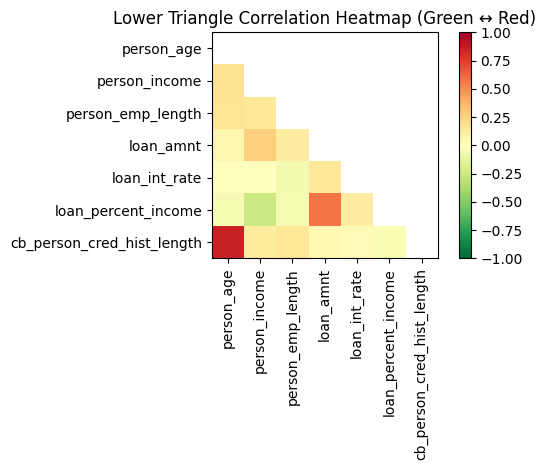

In [18]:
import numpy as np
import matplotlib.pyplot as plt

corr_matrix = X_train_num.corr(method='pearson')
# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# Apply mask
masked_corr = corr_matrix.mask(mask)
# Plot
plt.figure()
plt.imshow(masked_corr, cmap='RdYlGn_r', vmin=-1, vmax=1)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar()
plt.title('Lower Triangle Correlation Heatmap (Green ↔ Red)')
plt.tight_layout()
plt.show()

In [19]:
drop_columns_list = anova_results.iloc[7:, 0].to_list()
drop_columns_list.extend(chi2_result.iloc[4:, 0].to_list())
drop_columns_list.extend(['cb_person_cred_hist_length'])

def col_to_drop(df, columns_list):
    df.drop(columns = columns_list, inplace = True)

# apply to X_train
col_to_drop(X_train, drop_columns_list)

In [20]:
import pandas as pd

def create_dummies(df, cat_columns):
    df = df.copy()

    # Create dummy variables
    df_dummies = pd.get_dummies(df[cat_columns], drop_first=False)

    # Drop original categorical columns
    df.drop(columns=cat_columns, inplace=True)

    # Concatenate dummy variables
    df = pd.concat([df, df_dummies], axis=1)

    return df
cat_cols = X_train_cat.columns.tolist()
X_train = create_dummies(X_train, cat_cols)

In [21]:
col_to_drop(X_test, drop_columns_list)
X_test = create_dummies(X_test, cat_cols)

# reindex the dummied test set variables to make sure all the feature columns in the train set are also available in the test set
X_test = X_test.reindex(labels=X_train.columns, axis=1, fill_value=0)

In [22]:
## WoE Binning/Feature Engineering
X_train_prepr = X_train.copy()
y_train_prepr = y_train.copy()
X_test_prepr = X_test.copy()
y_test_prepr = y_test.copy()

In [23]:
import pandas as pd
import numpy as np

def woe_discrete(df, feature, target):
    # ---- handle target properly ----
    if isinstance(target, str):
        y = df[target]
    else:
        y = pd.Series(target, index=df.index)

    # ---- build working dataframe safely ----
    temp = pd.DataFrame({
        feature: df[feature],
        'target': y
    })

    # ---- group ----
    grouped = temp.groupby(feature)['target'].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']

    # ---- good ----
    grouped['good'] = grouped['total'] - grouped['bad']

    # ---- avoid divide-by-zero ----
    grouped['good'] = grouped['good'].replace(0, 0.5)
    grouped['bad'] = grouped['bad'].replace(0, 0.5)

    # ---- distributions ----
    grouped['dist_good'] = grouped['good'] / grouped['good'].sum()
    grouped['dist_bad'] = grouped['bad'] / grouped['bad'].sum()

    # ---- WOE ----
    grouped['WOE'] = np.log(grouped['dist_good'] / grouped['dist_bad'])

    # ---- IV calculation ----
    grouped['IV_component'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['WOE']
    iv = grouped['IV_component'].sum()

    # ---- reset index ----
    grouped = grouped.reset_index()

    return grouped, iv

In [24]:
sns.set()
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    y = df_WoE['WOE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df_WoE.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

In [25]:
df_temp,iv= woe_discrete(X_train_cat, 'loan_intent', y_train_prepr)
df_temp

,loan_intent,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,DEBTCONSOLIDATION,4165,1159,3006,0.147512,0.203834,-0.323396,0.018214
1,EDUCATION,5178,904,4274,0.209736,0.158987,0.277027,0.014059
2,HOMEIMPROVEMENT,2877,748,2129,0.104475,0.131551,-0.230444,0.006239
3,MEDICAL,4894,1312,3582,0.175778,0.230742,-0.272080,0.014955
4,PERSONAL,4378,884,3494,0.171459,0.155470,0.097897,0.001565
5,VENTURE,4572,679,3893,0.191039,0.119416,0.469865,0.033653


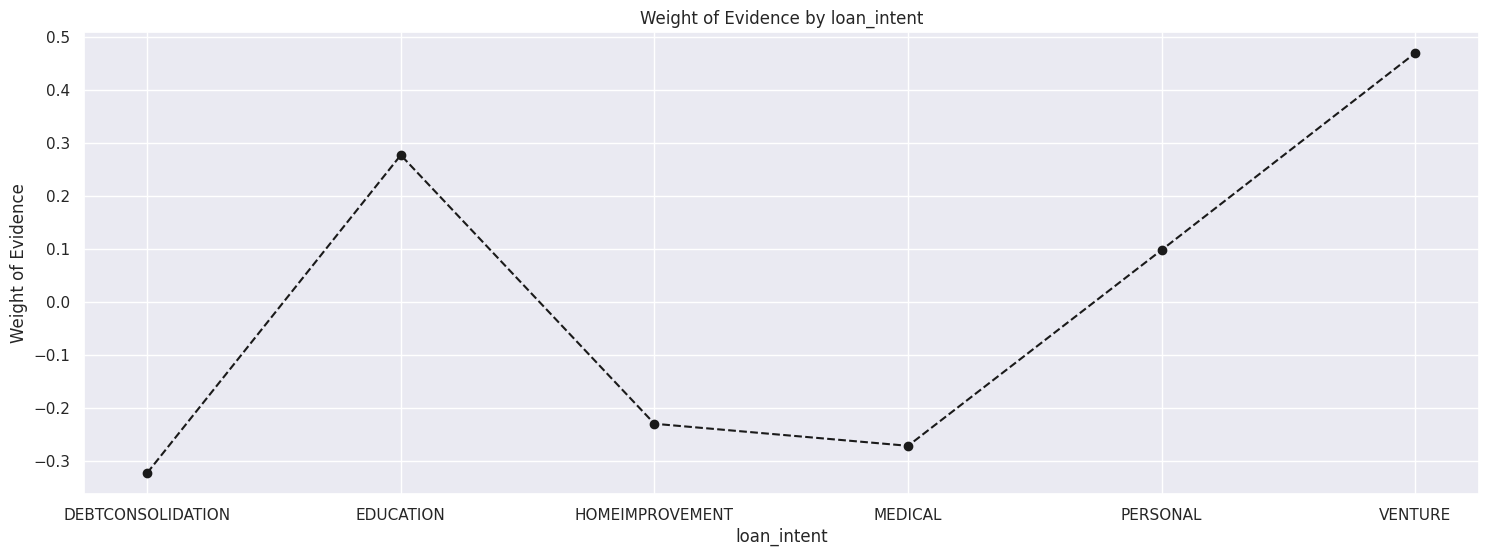

In [26]:
plot_by_woe(df_temp)

In [27]:
df_temp, iv = woe_discrete(X_train_cat, 'person_home_ownership', y_train_prepr.values.ravel())
df_temp

,person_home_ownership,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,MORTGAGE,10687,1324,9363,0.459466,0.232853,0.679659,0.154020
1,OTHER,89,29,60,0.002944,0.005100,-0.549400,0.001184
2,OWN,2090,153,1937,0.095053,0.026908,1.262009,0.086000
3,RENT,13198,4180,9018,0.442536,0.735139,-0.507538,0.148507


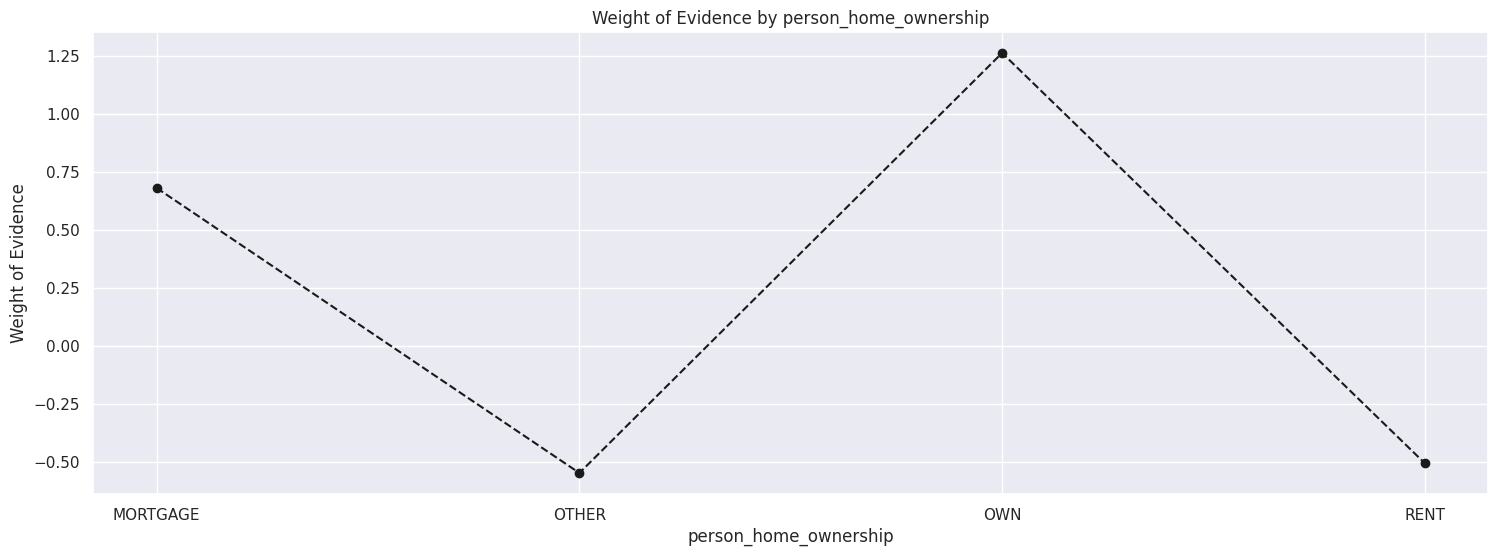

In [28]:
plot_by_woe(df_temp)

In [29]:
df_temp, iv = woe_discrete(X_train_cat, 'loan_grade', y_train_prepr.values.ravel())
df_temp

,loan_grade,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,A,8621,864,7757,0.380656,0.151952,0.918329,0.210025
1,B,8326,1370,6956,0.341349,0.240943,0.348345,0.034976
2,C,5232,1070,4162,0.204240,0.188181,0.081888,0.001315
3,D,2875,1706,1169,0.057366,0.300035,-1.654452,0.401485
4,E,771,494,277,0.013593,0.086880,-1.854967,0.135945
5,F,195,139,56,0.002748,0.024446,-2.185571,0.047422
6,G,44,43,1,0.000049,0.007562,-5.037649,0.037850


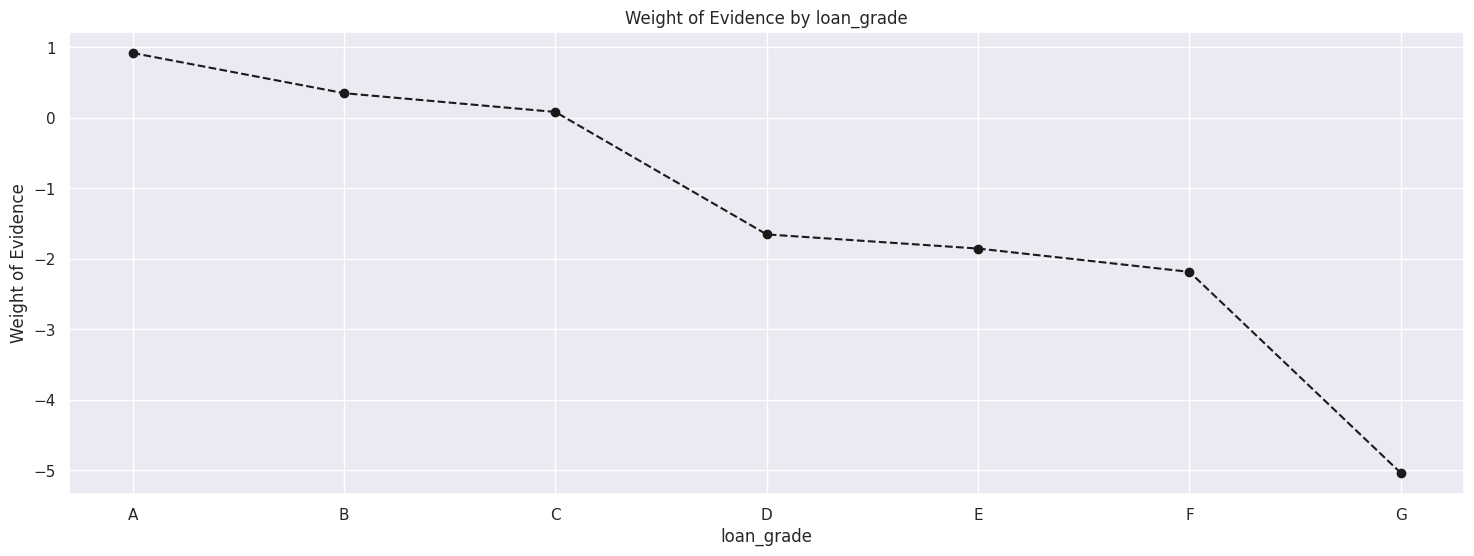

In [30]:
plot_by_woe(df_temp)

In [31]:
df_temp, iv = woe_discrete(X_train_cat, 'cb_person_default_on_file', y_train_prepr)
df_temp

,cb_person_default_on_file,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,N,21453,3948,17505,0.859015,0.694337,0.212829,0.035048
1,Y,4611,1738,2873,0.140985,0.305663,-0.773827,0.127432


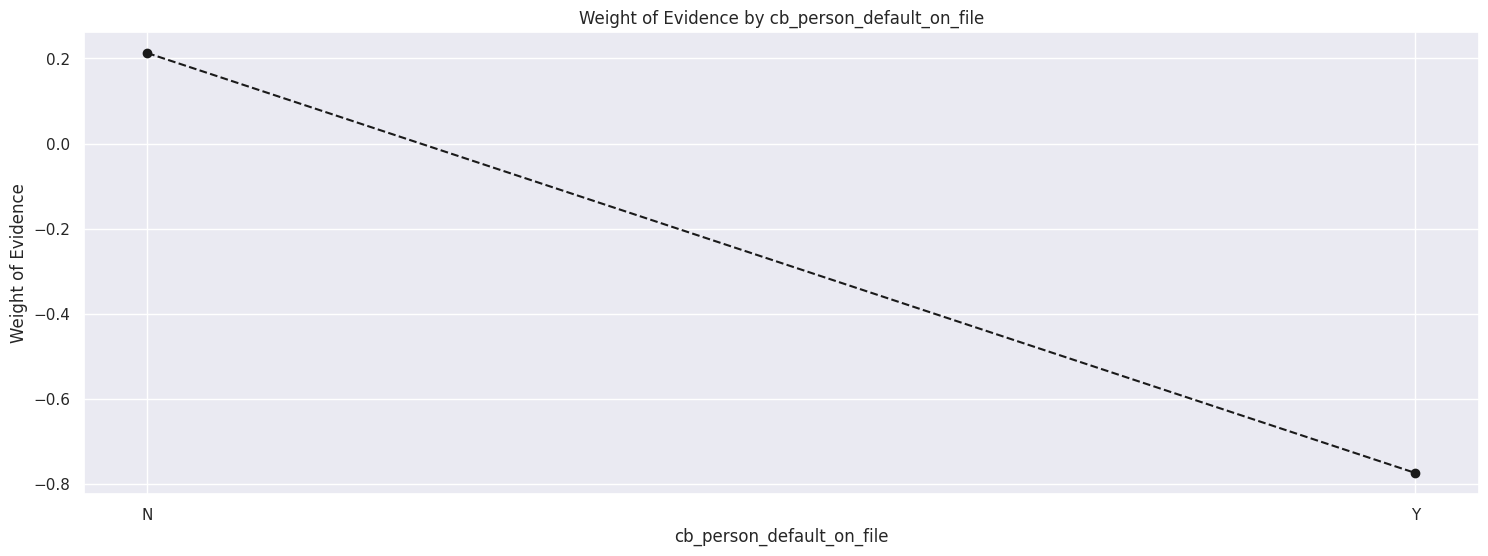

In [32]:
plot_by_woe(df_temp)

In [33]:
X_train_prepr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26064 entries, 15884 to 17068
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      26064 non-null  int64  
 1   person_income                   26064 non-null  int64  
 2   person_emp_length               25326 non-null  float64
 3   loan_amnt                       26064 non-null  int64  
 4   loan_int_rate                   23563 non-null  float64
 5   loan_percent_income             26064 non-null  float64
 6   person_home_ownership_MORTGAGE  26064 non-null  bool   
 7   person_home_ownership_OTHER     26064 non-null  bool   
 8   person_home_ownership_OWN       26064 non-null  bool   
 9   person_home_ownership_RENT      26064 non-null  bool   
 10  loan_intent_DEBTCONSOLIDATION   26064 non-null  bool   
 11  loan_intent_EDUCATION           26064 non-null  bool   
 12  loan_intent_HOMEIMPROVEMENT     2

In [34]:
import pandas as pd
import numpy as np

def woe_numerical(df, feature, target, bins=10):

    # ---- handle target ----
    if isinstance(target, str):
        y = df[target]
    else:
        y = pd.Series(target, index=df.index)

    # ---- create dataframe ----
    temp = pd.DataFrame({
        feature: df[feature],
        'target': y
    })

    # ---- create bins (quantile based) ----
    temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')

    # ---- group by bins ----
    grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']

    # ---- good ----
    grouped['good'] = grouped['total'] - grouped['bad']

    # ---- avoid division issues ----
    grouped['good'] = grouped['good'].replace(0, 0.5)
    grouped['bad'] = grouped['bad'].replace(0, 0.5)

    # ---- distributions ----
    grouped['dist_good'] = grouped['good'] / grouped['good'].sum()
    grouped['dist_bad'] = grouped['bad'] / grouped['bad'].sum()

    # ---- WOE ----
    grouped['WOE'] = np.log(grouped['dist_good'] / grouped['dist_bad'])

    # ---- IV ----
    grouped['IV_component'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['WOE']
    iv = grouped['IV_component'].sum()

    return grouped.reset_index(), iv

In [35]:
df_temp, iv = woe_numerical(X_train_num, 'person_income', y_train_prepr)
df_temp

/tmp/ipykernel_53441/3055066277.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])


,bin,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,"(3999.999, 28701.2]",2607,1231,1376,0.067524,0.216497,-1.165095,0.173568
1,"(28701.2, 35000.0]",2692,1064,1628,0.079890,0.187126,-0.851132,0.091272
2,"(35000.0, 42000.0]",2862,656,2206,0.108254,0.115371,-0.063673,0.000453
3,"(42000.0, 48996.0]",2272,511,1761,0.086417,0.089870,-0.039181,0.000135
4,"(48996.0, 55000.0]",2676,536,2140,0.105015,0.094267,0.107978,0.001161
5,"(55000.0, 63000.0]",2574,460,2114,0.103739,0.080900,0.248662,0.005679
6,"(63000.0, 73000.0]",2625,403,2222,0.109039,0.070876,0.430778,0.016440
7,"(73000.0, 86000.0]",2597,358,2239,0.109873,0.062962,0.556803,0.026121
8,"(86000.0, 110000.0]",2557,231,2326,0.114143,0.040626,1.033039,0.075946
9,"(110000.0, 6000000.0]",2602,236,2366,0.116106,0.041505,1.028675,0.076739


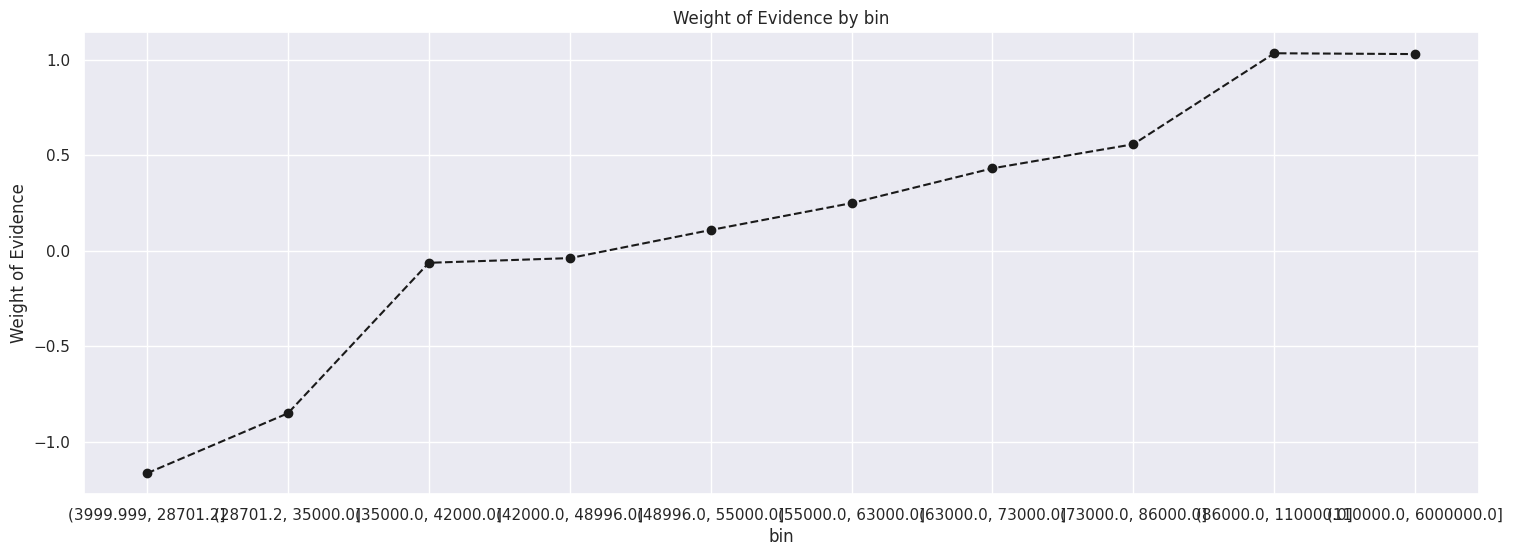

In [36]:

plot_by_woe(df_temp)

In [37]:
df_temp, iv = woe_numerical(X_train_num, 'person_emp_length', y_train_prepr)
df_temp

/tmp/ipykernel_53441/3055066277.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])


,bin,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,"(-0.001, 1.0]",5591,1540,4051,0.203814,0.282569,-0.326716,0.025731
1,"(1.0, 2.0]",3082,805,2277,0.114560,0.147706,-0.254126,0.008423
2,"(2.0, 3.0]",2768,560,2208,0.111089,0.102752,0.078008,0.000650
3,"(3.0, 4.0]",2326,489,1837,0.092423,0.089725,0.029629,0.000080
4,"(4.0, 5.0]",2335,439,1896,0.095391,0.080550,0.169105,0.002510
5,"(5.0, 6.0]",2128,393,1735,0.087291,0.072110,0.191056,0.002900
6,"(6.0, 8.0]",3101,552,2549,0.128245,0.101284,0.236011,0.006363
7,"(8.0, 10.0]",1657,296,1361,0.068475,0.054312,0.231718,0.003282
8,"(10.0, 123.0]",2338,376,1962,0.098712,0.068991,0.358233,0.010647


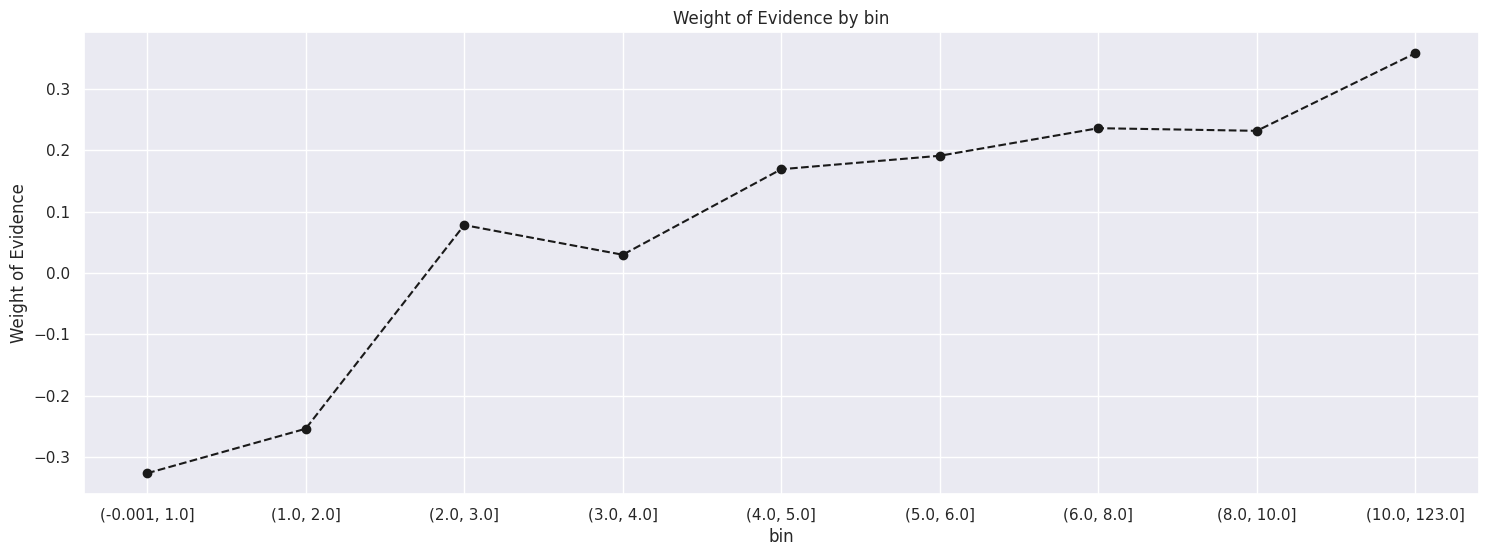

In [38]:
plot_by_woe(df_temp)

In [39]:
df_temp, iv = woe_numerical(X_train_num, 'loan_amnt', y_train_prepr)
df_temp

/tmp/ipykernel_53441/3055066277.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])


,bin,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,"(499.999, 3000.0]",3187,686,2501,0.122730,0.120647,0.017119,0.000036
1,"(3000.0, 4400.0]",2031,414,1617,0.079350,0.072810,0.086013,0.000563
2,"(4400.0, 5500.0]",2779,535,2244,0.110119,0.094091,0.157300,0.002521
3,"(5500.0, 6800.0]",2464,379,2085,0.102316,0.066655,0.428539,0.015282
4,"(6800.0, 8000.0]",3002,528,2474,0.121405,0.092860,0.268046,0.007652
5,"(8000.0, 10000.0]",3785,726,3059,0.150113,0.127682,0.161844,0.003630
6,"(10000.0, 12000.0]",2310,467,1843,0.090441,0.082132,0.096372,0.000801
7,"(12000.0, 14500.0]",1354,346,1008,0.049465,0.060851,-0.207164,0.002359
8,"(14500.0, 19000.0]",2592,718,1874,0.091962,0.126275,-0.317088,0.010880
9,"(19000.0, 35000.0]",2560,887,1673,0.082098,0.155997,-0.641920,0.047437


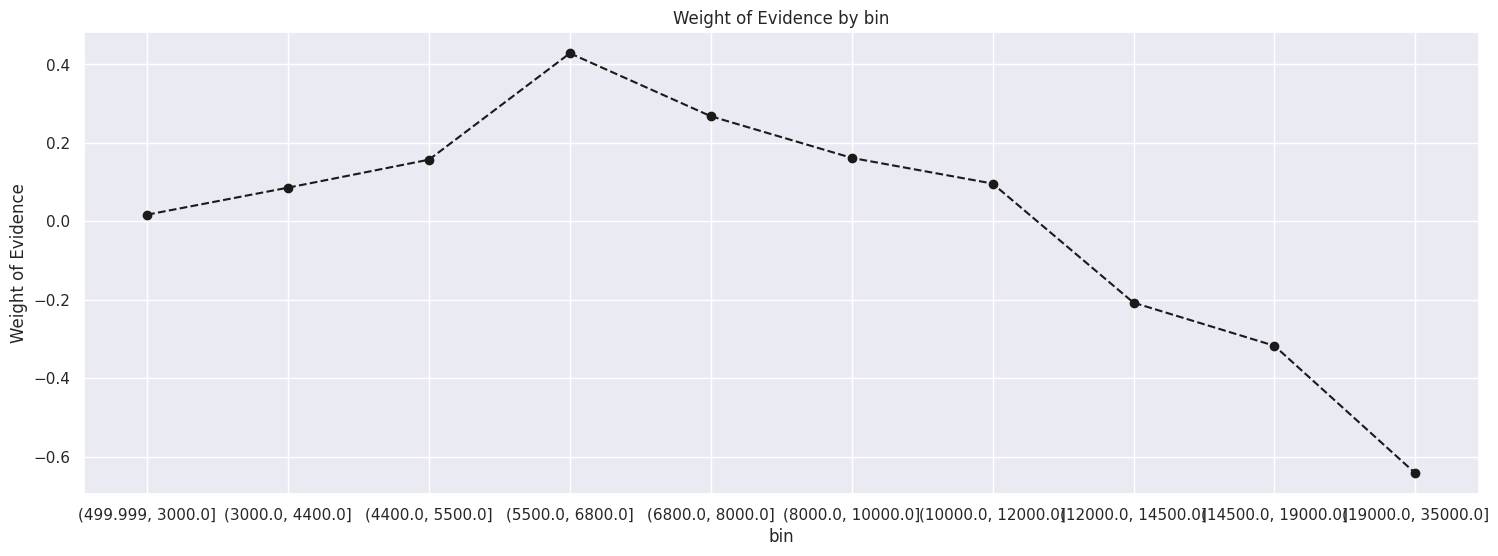

In [40]:
plot_by_woe(df_temp)

In [41]:
df_temp, iv = woe_numerical(X_train_num, 'loan_int_rate', y_train_prepr)
df_temp

/tmp/ipykernel_53441/3055066277.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])


,bin,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,"(5.419, 6.91]",2562,211,2351,0.127716,0.040931,1.137920,0.098754
1,"(6.91, 7.51]",2239,223,2016,0.109518,0.043259,0.928881,0.061546
2,"(7.51, 8.9]",2528,301,2227,0.120980,0.058390,0.728482,0.045596
3,"(8.9, 10.25]",2224,330,1894,0.102890,0.064016,0.474535,0.018447
4,"(10.25, 10.99]",2347,381,1966,0.106801,0.073909,0.368139,0.012109
5,"(10.99, 11.86]",2293,396,1897,0.103053,0.076819,0.293797,0.007708
6,"(11.86, 12.87]",2331,448,1883,0.102292,0.086906,0.163010,0.002508
7,"(12.87, 13.92]",2344,509,1835,0.099685,0.098739,0.009534,0.000009
8,"(13.92, 15.28]",2349,936,1413,0.076760,0.181571,-0.860963,0.090239
9,"(15.28, 22.48]",2346,1420,926,0.050304,0.275461,-1.700356,0.382846


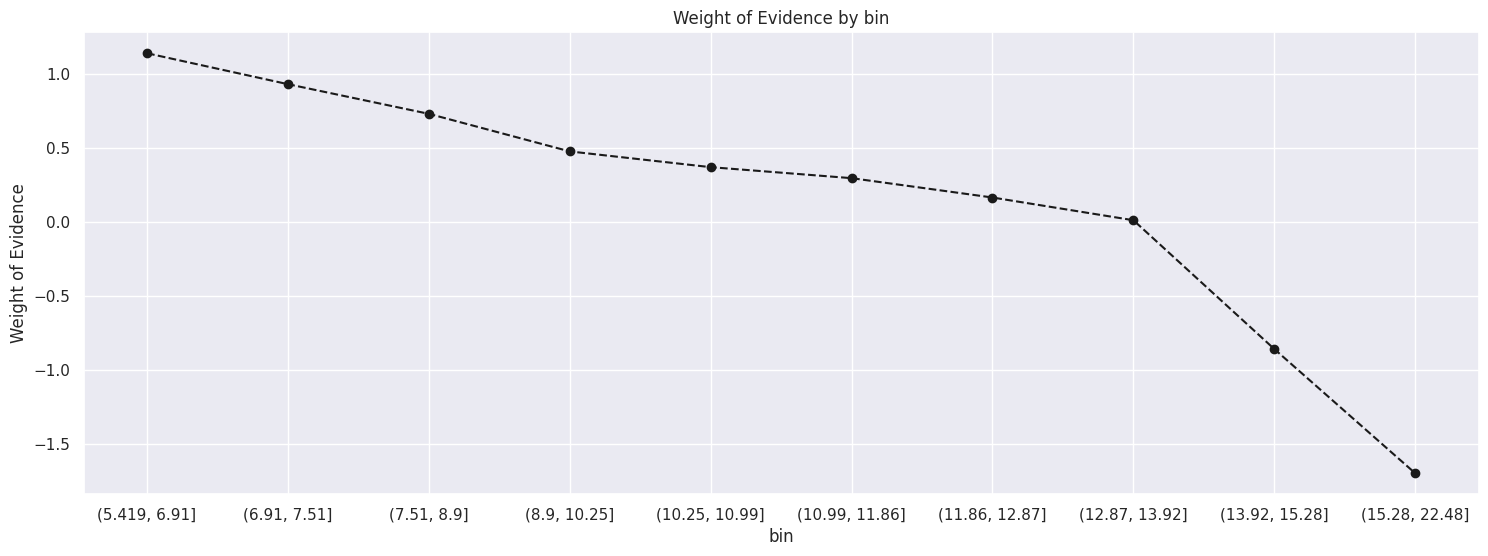

In [42]:
plot_by_woe(df_temp)

In [43]:
df_temp, iv = woe_numerical(X_train_num, 'loan_percent_income', y_train_prepr)
df_temp

/tmp/ipykernel_53441/3055066277.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])


,bin,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,"(-0.001, 0.05]",2775,278,2497,0.122534,0.048892,0.918775,0.067661
1,"(0.05, 0.08]",3273,414,2859,0.140298,0.072810,0.655912,0.044266
2,"(0.08, 0.1]",2329,297,2032,0.099715,0.052234,0.646595,0.030701
3,"(0.1, 0.12]",2138,255,1883,0.092404,0.044847,0.722909,0.034379
4,"(0.12, 0.15]",3214,416,2798,0.137305,0.073162,0.629526,0.040380
5,"(0.15, 0.18]",2687,482,2205,0.108205,0.084770,0.244090,0.005720
6,"(0.18, 0.21]",2333,442,1891,0.092796,0.077735,0.177102,0.002667
7,"(0.21, 0.25]",2324,451,1873,0.091913,0.079318,0.147380,0.001856
8,"(0.25, 0.32]",2507,894,1613,0.079154,0.157228,-0.686304,0.053583
9,"(0.32, 0.83]",2484,1757,727,0.035676,0.309005,-2.158885,0.590086


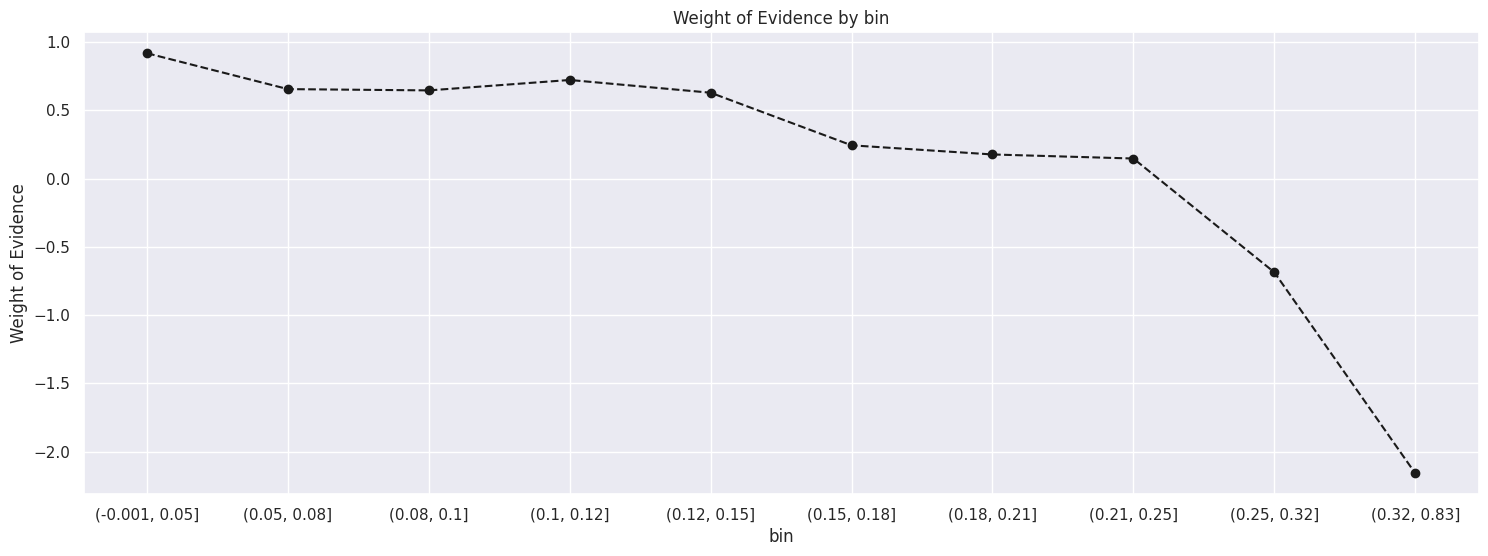

In [44]:
plot_by_woe(df_temp)

In [45]:
df_temp, iv = woe_numerical(X_train_num, 'person_age', y_train_prepr)
df_temp

/tmp/ipykernel_53441/3055066277.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby('bin')['target'].agg(['count', 'sum'])


,bin,total,bad,good,dist_good,dist_bad,WOE,IV_component
0,"(19.999, 22.0]",3912,1011,2901,0.142359,0.177805,-0.222333,0.007881
1,"(22.0, 23.0]",3125,675,2450,0.120228,0.118713,0.012682,0.000019
2,"(23.0, 24.0]",2829,602,2227,0.109285,0.105874,0.031704,0.000108
3,"(24.0, 25.0]",2451,544,1907,0.093581,0.095674,-0.022112,0.000046
4,"(25.0, 26.0]",1988,414,1574,0.077240,0.072810,0.059061,0.000262
5,"(26.0, 27.0]",1700,360,1340,0.065757,0.063313,0.037872,0.000093
6,"(27.0, 29.0]",2815,592,2223,0.109088,0.104115,0.046657,0.000232
7,"(29.0, 32.0]",2751,549,2202,0.108058,0.096553,0.112574,0.001295
8,"(32.0, 36.0]",2192,456,1736,0.085190,0.080197,0.060397,0.000302
9,"(36.0, 144.0]",2301,483,1818,0.089214,0.084945,0.049027,0.000209


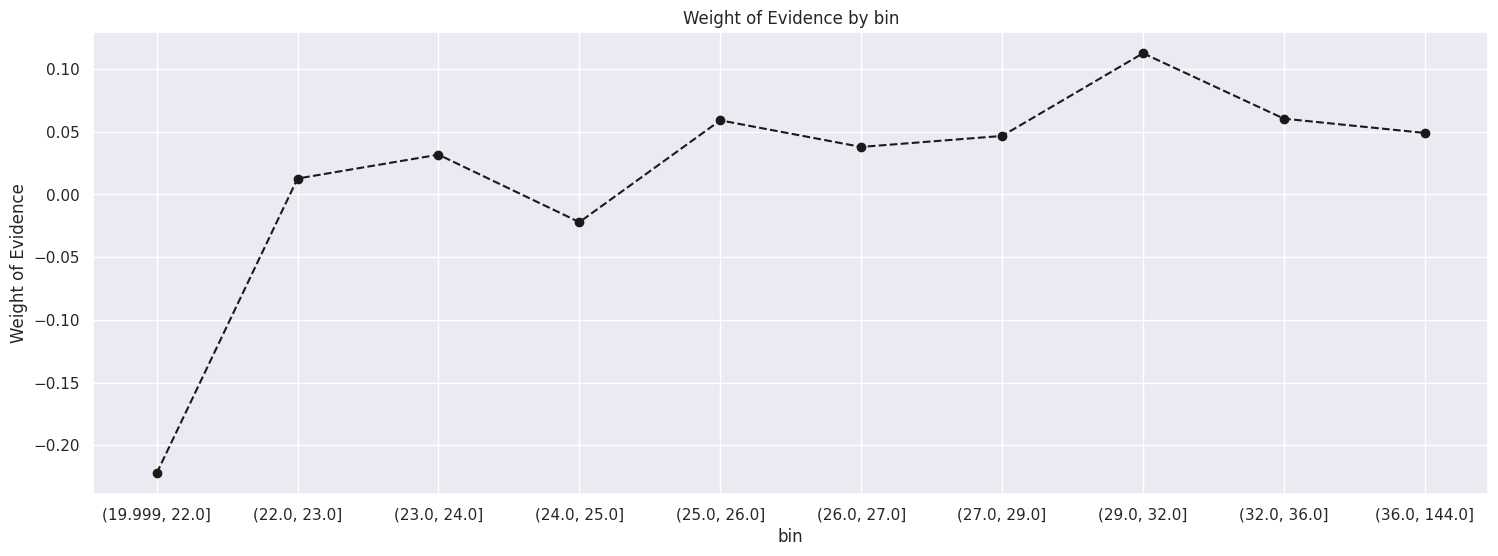

In [46]:
plot_by_woe(df_temp)

In [65]:
ref_categories  : ['loan_intent_PERSONAL','person_home_ownership_RENT', 'loan_grade_C', 'cb_person_default_on_file_N', 'person_income:42000-48996',
                   'emp_length:3-4', 'loan_amnt:10000-12000', 'int_rate:12.87-13.92', 'loan_pct_income:0.21-0.25', 'age:22-23']

In [66]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26064 entries, 15884 to 17068
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      26064 non-null  int64  
 1   person_income                   26064 non-null  int64  
 2   person_emp_length               25326 non-null  float64
 3   loan_amnt                       26064 non-null  int64  
 4   loan_int_rate                   23563 non-null  float64
 5   loan_percent_income             26064 non-null  float64
 6   person_home_ownership_MORTGAGE  26064 non-null  bool   
 7   person_home_ownership_OTHER     26064 non-null  bool   
 8   person_home_ownership_OWN       26064 non-null  bool   
 9   person_home_ownership_RENT      26064 non-null  bool   
 10  loan_intent_DEBTCONSOLIDATION   26064 non-null  bool   
 11  loan_intent_EDUCATION           26064 non-null  bool   
 12  loan_intent_HOMEIMPROVEMENT     2

In [79]:
class WoE_Binning(BaseEstimator, TransformerMixin):
    def __init__(self, ref_categories=None):
        self.ref_categories = ref_categories if ref_categories is not None else []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X_new = pd.DataFrame(index=X.index)
        X_new['person_home_ownership_MORTGAGE'] = X.loc[:,'person_home_ownership_MORTGAGE']
        X_new['person_home_ownership_OTHER'] = X.loc[:,'person_home_ownership_OTHER']
        X_new['person_home_ownership_OWN'] = X.loc[:,'person_home_ownership_OWN']
        X_new['person_home_ownership_RENT'] = X.loc[:,'person_home_ownership_RENT']

        X_new['loan_intent_DEBTCONSOLIDATION'] = X.loc[:,'loan_intent_DEBTCONSOLIDATION']
        X_new['loan_intent_EDUCATION'] = X.loc[:,'loan_intent_EDUCATION']
        X_new['loan_intent_HOMEIMPROVEMENT'] = X.loc[:,'loan_intent_HOMEIMPROVEMENT']
        X_new['loan_intent_MEDICAL'] = X.loc[:,'loan_intent_MEDICAL']
        X_new['loan_intent_PERSONAL'] = X.loc[:,'loan_intent_PERSONAL']
        X_new['loan_intent_VENTURE'] = X.loc[:,'loan_intent_VENTURE']


        X_new['loan_grade_A'] = X.loc[:,'loan_grade_A']
        X_new['loan_grade_B'] = X.loc[:,'loan_grade_B']
        X_new['loan_grade_C'] = X.loc[:,'loan_grade_C']
        X_new['loan_grade_D'] = X.loc[:,'loan_grade_D']
        X_new['loan_grade_E'] = X.loc[:,'loan_grade_E']
        X_new['loan_grade_F'] = X.loc[:,'loan_grade_F']
        X_new['loan_grade_G'] = X.loc[:,'loan_grade_G']

        X_new['cb_person_default_on_file_N'] = X.loc[:,'cb_person_default_on_file_N']
        X_new['cb_person_default_on_file_Y'] = X.loc[:,'cb_person_default_on_file_Y']

        X_new['person_income:missing'] = np.where(X['person_income'].isnull(), 1, 0)
        X_new['person_income:<28701'] = np.where(X['person_income'] <= 28701.2, 1, 0)
        X_new['person_income:28701-35000'] = np.where((X['person_income'] > 28701.2) & (X['person_income'] <= 35000), 1, 0)
        X_new['person_income:35000-42000'] = np.where((X['person_income'] > 35000) & (X['person_income'] <= 42000), 1, 0)
        X_new['person_income:42000-48996'] = np.where((X['person_income'] > 42000) & (X['person_income'] <= 48996), 1, 0)
        X_new['person_income:48996-55000'] = np.where((X['person_income'] > 48996) & (X['person_income'] <= 55000), 1, 0)
        X_new['person_income:55000-63000'] = np.where((X['person_income'] > 55000) & (X['person_income'] <= 63000), 1, 0)
        X_new['person_income:63000-73000'] = np.where((X['person_income'] > 63000) & (X['person_income'] <= 73000), 1, 0)
        X_new['person_income:73000-86000'] = np.where((X['person_income'] > 73000) & (X['person_income'] <= 86000), 1, 0)
        X_new['person_income:86000-110000'] = np.where((X['person_income'] > 86000) & (X['person_income'] <= 110000), 1, 0)
        X_new['person_income:>110000'] = np.where(X['person_income'] > 110000, 1, 0)

        X_new['emp_length:missing'] = np.where(X['person_emp_length'].isnull(), 1, 0)
        X_new['emp_length:<=1'] = np.where(X['person_emp_length'] <= 1, 1, 0)
        X_new['emp_length:1-2'] = np.where((X['person_emp_length'] > 1) & (X['person_emp_length'] <= 2), 1, 0)
        X_new['emp_length:2-3'] = np.where((X['person_emp_length'] > 2) & (X['person_emp_length'] <= 3), 1, 0)
        X_new['emp_length:3-4'] = np.where((X['person_emp_length'] > 3) & (X['person_emp_length'] <= 4), 1, 0)
        X_new['emp_length:4-5'] = np.where((X['person_emp_length'] > 4) & (X['person_emp_length'] <= 5), 1, 0)
        X_new['emp_length:5-6'] = np.where((X['person_emp_length'] > 5) & (X['person_emp_length'] <= 6), 1, 0)
        X_new['emp_length:6-8'] = np.where((X['person_emp_length'] > 6) & (X['person_emp_length'] <= 8), 1, 0)
        X_new['emp_length:8-10'] = np.where((X['person_emp_length'] > 8) & (X['person_emp_length'] <= 10), 1, 0)
        X_new['emp_length:>10'] = np.where(X['person_emp_length'] > 10, 1, 0)

        X_new['loan_amnt:missing'] = np.where(X['loan_amnt'].isnull(), 1, 0)
        X_new['loan_amnt:<3000'] = np.where(X['loan_amnt'] <= 3000, 1, 0)
        X_new['loan_amnt:3000-4400'] = np.where((X['loan_amnt'] > 3000) & (X['loan_amnt'] <= 4400), 1, 0)
        X_new['loan_amnt:4400-5500'] = np.where((X['loan_amnt'] > 4400) & (X['loan_amnt'] <= 5500), 1, 0)
        X_new['loan_amnt:5500-6800'] = np.where((X['loan_amnt'] > 5500) & (X['loan_amnt'] <= 6800), 1, 0)
        X_new['loan_amnt:6800-8000'] = np.where((X['loan_amnt'] > 6800) & (X['loan_amnt'] <= 8000), 1, 0)
        X_new['loan_amnt:8000-10000'] = np.where((X['loan_amnt'] > 8000) & (X['loan_amnt'] <= 10000), 1, 0)
        X_new['loan_amnt:10000-12000'] = np.where((X['loan_amnt'] > 10000) & (X['loan_amnt'] <= 12000), 1, 0)
        X_new['loan_amnt:12000-14500'] = np.where((X['loan_amnt'] > 12000) & (X['loan_amnt'] <= 14500), 1, 0)
        X_new['loan_amnt:14500-19000'] = np.where((X['loan_amnt'] > 14500) & (X['loan_amnt'] <= 19000), 1, 0)
        X_new['loan_amnt:>19000'] = np.where(X['loan_amnt'] > 19000, 1, 0)

        X_new['int_rate:missing'] = np.where(X['loan_int_rate'].isnull(), 1, 0)
        X_new['int_rate:<6.91'] = np.where(X['loan_int_rate'] <= 6.91, 1, 0)
        X_new['int_rate:6.91-7.51'] = np.where((X['loan_int_rate'] > 6.91) & (X['loan_int_rate'] <= 7.51), 1, 0)
        X_new['int_rate:7.51-8.9'] = np.where((X['loan_int_rate'] > 7.51) & (X['loan_int_rate'] <= 8.9), 1, 0)
        X_new['int_rate:8.9-10.25'] = np.where((X['loan_int_rate'] > 8.9) & (X['loan_int_rate'] <= 10.25), 1, 0)
        X_new['int_rate:10.25-10.99'] = np.where((X['loan_int_rate'] > 10.25) & (X['loan_int_rate'] <= 10.99), 1, 0)
        X_new['int_rate:10.99-11.86'] = np.where((X['loan_int_rate'] > 10.99) & (X['loan_int_rate'] <= 11.86), 1, 0)
        X_new['int_rate:11.86-12.87'] = np.where((X['loan_int_rate'] > 11.86) & (X['loan_int_rate'] <= 12.87), 1, 0)
        X_new['int_rate:12.87-13.92'] = np.where((X['loan_int_rate'] > 12.87) & (X['loan_int_rate'] <= 13.92), 1, 0)
        X_new['int_rate:13.92-15.28'] = np.where((X['loan_int_rate'] > 13.92) & (X['loan_int_rate'] <= 15.28), 1, 0)
        X_new['int_rate:>15.28'] = np.where(X['loan_int_rate'] > 15.28, 1, 0)

        X_new['loan_pct_income:missing'] = np.where(X['loan_percent_income'].isnull(), 1, 0)
        X_new['loan_pct_income:<=0.05'] = np.where(X['loan_percent_income'] <= 0.05, 1, 0)
        X_new['loan_pct_income:0.05-0.08'] = np.where((X['loan_percent_income'] > 0.05) & (X['loan_percent_income'] <= 0.08), 1, 0)
        X_new['loan_pct_income:0.08-0.10'] = np.where((X['loan_percent_income'] > 0.08) & (X['loan_percent_income'] <= 0.10), 1, 0)
        X_new['loan_pct_income:0.10-0.12'] = np.where((X['loan_percent_income'] > 0.10) & (X['loan_percent_income'] <= 0.12), 1, 0)
        X_new['loan_pct_income:0.12-0.15'] = np.where((X['loan_percent_income'] > 0.12) & (X['loan_percent_income'] <= 0.15), 1, 0)
        X_new['loan_pct_income:0.15-0.18'] = np.where((X['loan_percent_income'] > 0.15) & (X['loan_percent_income'] <= 0.18), 1, 0)
        X_new['loan_pct_income:0.18-0.21'] = np.where((X['loan_percent_income'] > 0.18) & (X['loan_percent_income'] <= 0.21), 1, 0)
        X_new['loan_pct_income:0.21-0.25'] = np.where((X['loan_percent_income'] > 0.21) & (X['loan_percent_income'] <= 0.25), 1, 0)
        X_new['loan_pct_income:0.25-0.32'] = np.where((X['loan_percent_income'] > 0.25) & (X['loan_percent_income'] <= 0.32), 1, 0)
        X_new['loan_pct_income:>0.32'] = np.where(X['loan_percent_income'] > 0.32, 1, 0)

        X_new['age:missing'] = np.where(X['person_age'].isnull(), 1, 0)
        X_new['age:<=22'] = np.where(X['person_age'] <= 22, 1, 0)
        X_new['age:22-23'] = np.where((X['person_age'] > 22) & (X['person_age'] <= 23), 1, 0)
        X_new['age:23-24'] = np.where((X['person_age'] > 23) & (X['person_age'] <= 24), 1, 0)
        X_new['age:24-25'] = np.where((X['person_age'] > 24) & (X['person_age'] <= 25), 1, 0)
        X_new['age:25-26'] = np.where((X['person_age'] > 25) & (X['person_age'] <= 26), 1, 0)
        X_new['age:26-27'] = np.where((X['person_age'] > 26) & (X['person_age'] <= 27), 1, 0)
        X_new['age:27-29'] = np.where((X['person_age'] > 27) & (X['person_age'] <= 29), 1, 0)
        X_new['age:29-32'] = np.where((X['person_age'] > 29) & (X['person_age'] <= 32), 1, 0)
        X_new['age:32-36'] = np.where((X['person_age'] > 32) & (X['person_age'] <= 36), 1, 0)
        X_new['age:>36'] = np.where(X['person_age'] > 36, 1, 0)
        X_new.drop(columns = self.ref_categories, inplace = True)
        return X_new


## PD Model

In [80]:
# reconfirm shape of the 4 datasets
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(26064, 25)
(26064,)
(6517, 25)
(6517,)


In [88]:
# define modeling pipeline
reg = LogisticRegression(max_iter=1000, class_weight = 'balanced')
woe_transform = WoE_Binning()
pipeline = Pipeline(steps=[('woe', woe_transform), ('model', reg)])

# define cross-validation criteria. RepeatedStratifiedKFold automatially takes care of the class imbalance while splitting
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)

# fit and evaluate the logistic regression pipeline with cross-validation as defined in cv
scores = cross_val_score(pipeline, X_train, y_train, scoring = 'roc_auc', cv = cv)
AUROC = np.mean(scores)
GINI = AUROC * 2 - 1

# print the mean AUROC score and Gini
print('Mean AUROC: %.4f' % (AUROC))
print('Gini: %.4f' % (GINI))

Mean AUROC: 0.8833
Gini: 0.7666


In [89]:
# pretty impressive scores for the first time, now let's fit the pipeline on the whole training set
pipeline.fit(X_train, y_train)

Pipeline(steps=[('woe', WoE_Binning(ref_categories=[])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [83]:
#first create a transformed training set through our WoE_Binning custom class
X_train_woe_transformed = woe_transform.fit_transform(X_train)
# Store the column names in X_train as a list
feature_name = X_train_woe_transformed.columns.values
# Create a summary table of our logistic regression model
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Create a new column in the dataframe, called 'Coefficients', with row values the transposed coefficients from the 'LogisticRegression' model
summary_table['Coefficients'] = np.transpose(pipeline['model'].coef_)
# Increase the index of every row of the dataframe with 1 to store our model intercept in 1st row
summary_table.index = summary_table.index + 1
# Assign our model intercept to this new row
summary_table.loc[0] = ['Intercept', pipeline['model'].intercept_[0]]
# Sort the dataframe by index
summary_table.sort_index(inplace = True)
summary_table

,Feature name,Coefficients
0,Intercept,0.174153
1,person_home_ownership_MORTGAGE,0.271380
2,person_home_ownership_OTHER,0.618337
3,person_home_ownership_OWN,-1.612320
4,person_home_ownership_RENT,0.888314
...,...,...
80,age:26-27,-0.043951
81,age:27-29,0.022025
82,age:29-32,-0.042875
83,age:32-36,0.015682


In [84]:
X_train_woe_transformed

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y,person_income:missing,person_income:<28701,person_income:28701-35000,person_income:35000-42000,person_income:42000-48996,person_income:48996-55000,person_income:55000-63000,person_income:63000-73000,person_income:73000-86000,person_income:86000-110000,person_income:>110000,emp_length:missing,emp_length:<=1,emp_length:1-2,emp_length:2-3,emp_length:3-4,emp_length:4-5,emp_length:5-6,emp_length:6-8,emp_length:8-10,emp_length:>10,loan_amnt:missing,loan_amnt:<3000,loan_amnt:3000-4400,loan_amnt:4400-5500,loan_amnt:5500-6800,loan_amnt:6800-8000,loan_amnt:8000-10000,loan_amnt:10000-12000,loan_amnt:12000-14500,loan_amnt:14500-19000,loan_amnt:>19000,int_rate:missing,int_rate:<6.91,int_rate:6.91-7.51,int_rate:7.51-8.9,int_rate:8.9-10.25,int_rate:10.25-10.99,int_rate:10.99-11.86,int_rate:11.86-12.87,int_rate:12.87-13.92,int_rate:13.92-15.28,int_rate:>15.28,loan_pct_income:missing,loan_pct_income:<=0.05,loan_pct_income:0.05-0.08,loan_pct_income:0.08-0.10,loan_pct_income:0.10-0.12,loan_pct_income:0.12-0.15,loan_pct_income:0.15-0.18,loan_pct_income:0.18-0.21,loan_pct_income:0.21-0.25,loan_pct_income:0.25-0.32,loan_pct_income:>0.32,age:missing,age:<=22,age:22-23,age:23-24,age:24-25,age:25-26,age:26-27,age:27-29,age:29-32,age:32-36,age:>36
15884,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
15138,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7474,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
18212,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
6493,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14621,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
18736,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
1663,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
18257,False,False,False,True,False,False,True,False,

## Prediction

In [107]:
import pandas as pd
import numpy as np

# 🔧 Set your custom threshold here
threshold = 0.6   # try 0.3, 0.4, 0.5, 0.6 etc.

# 1. Get probabilities (class = 1)
y_hat_test_proba = pipeline.predict_proba(X_test)[:, 1]

# 2. Create predictions using custom threshold
y_hat_test_custom = (y_hat_test_proba >= threshold).astype(int)

# 3. Prepare actual values
y_test_temp = y_test.reset_index(drop=True)

# 4. Create final dataframe
results_df = pd.DataFrame({
    'actual': y_test_temp,
    'probability': y_hat_test_proba,
    'prediction_default_0.5': pipeline.predict(X_test),   # original
    'prediction_custom': y_hat_test_custom                # adjusted
})

# 5. Align index
results_df.index = X_test.index

# View result
results_df.head()

,actual,probability,prediction_default_0.5,prediction_custom
6616,0,0.215781,0,0
21802,0,0.139210,0,0
31886,0,0.048221,0,0
17799,0,0.148364,0,0
5207,0,0.041766,0,0


In [110]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# ---- 1. Get probabilities ----
y_hat_test_proba = pipeline.predict_proba(X_test)[:, 1]

# ---- 2. Default threshold (0.5) ----
y_pred_default = (y_hat_test_proba >= 0.5).astype(int)

# ---- 3. Custom threshold (change here) ----
custom_threshold = 0.7
y_pred_custom = (y_hat_test_proba >= custom_threshold).astype(int)

# ---- 4. Create DataFrame ----
y_test_temp = y_test.reset_index(drop=True)

results_df = pd.DataFrame({
    'actual': y_test_temp,
    'probability': y_hat_test_proba,
    'prediction_default_0.5': y_pred_default,
    f'prediction_custom_{custom_threshold}': y_pred_custom
})

# ---- 5. Metrics function ----
def evaluate_model(actual, pred, prob):
    precision = precision_score(actual, pred)
    recall = recall_score(actual, pred)
    auc = roc_auc_score(actual, prob)
    gini = 2 * auc - 1
    return precision, recall, auc, gini

# ---- 6. Evaluate both ----
precision_d, recall_d, auc_d, gini_d = evaluate_model(
    results_df['actual'],
    results_df['prediction_default_0.5'],
    results_df['probability']
)

precision_c, recall_c, auc_c, gini_c = evaluate_model(
    results_df['actual'],
    results_df[f'prediction_custom_{custom_threshold}'],
    results_df['probability']
)

# ---- 7. Print Results ----
print("===== DEFAULT THRESHOLD (0.5) =====")
print(f"Precision: {precision_d:.4f}")
print(f"Recall:    {recall_d:.4f}")
print(f"AUC:       {auc_d:.4f}")
print(f"Gini:      {gini_d:.4f}")

print("\n===== CUSTOM THRESHOLD =====")
print(f"Threshold: {custom_threshold}")
print(f"Precision: {precision_c:.4f}")
print(f"Recall:    {recall_c:.4f}")
print(f"AUC:       {auc_c:.4f}")
print(f"Gini:      {gini_c:.4f}")

===== DEFAULT THRESHOLD (0.5) =====
Precision: 0.5639
Recall:    0.7848
AUC:       0.8832
Gini:      0.7664

===== CUSTOM THRESHOLD =====
Threshold: 0.7
Precision: 0.6949
Recall:    0.6744
AUC:       0.8832
Gini:      0.7664
